# 🔤 Byte Pair Encoding (BPE)
## Parallel Implementation: Sequential · OpenMP · MPI · CUDA · MPI+CUDA Hybrid
### Penn Treebank Dataset  |  Full Analytical Pipeline

This notebook implements **BPE tokenization from scratch** in C/C++, then accelerates it with:
- 🔵 **OpenMP** — shared-memory multi-threading
- 🟠 **MPI** — distributed-memory parallelism
- 🟢 **CUDA** — GPU-accelerated pair counting
- 🔴 **MPI+CUDA Hybrid**

---
> **Environment:** Google Colab (T4 GPU recommended) · Runtime → Change runtime type → **GPU**


## 0. Environment Setup

In [19]:
# Install MPI and check CUDA
!apt-get update -qq
!apt-get install -y -qq mpich libmpich-dev 2>/dev/null
!nvcc --version 2>/dev/null || echo 'No CUDA compiler — some cells will be skipped'
!mpicc --version 2>/dev/null
!echo 'CPU cores:' $(nproc)
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null || echo 'No GPU detected'

import os, time, json, subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict, Counter
import pandas as pd

# ── colour palette ──
COLORS = {'sequential':'#4C72B0', 'openmp':'#DD8452',
          'mpi':'#55A868', 'cuda':'#C44E52'}

HAVE_GPU = subprocess.run('nvidia-smi', shell=True,
           capture_output=True).returncode == 0
print(f'GPU available: {HAVE_GPU}')


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

CPU cores: 2
Tesla T4, 15360 MiB
GPU available: True


## 1. Load Penn Treebank Data

In [20]:
# from google.colab import files
# uploaded = files.upload()   # ptb_train.txt, ptb_valid.txt, ptb_test.txt

# ── write small demo corpus if files are absent ──
DEMO = not (os.path.exists('ptb_train.txt') or
            os.path.exists('/content/ptb_train.txt'))

def load_file(name):
    for p in [name, f'/content/{name}']:
        if os.path.exists(p):
            return open(p).read()
    return None

train_text = load_file('ptb_train.txt')
valid_text = load_file('ptb_valid.txt')
test_text  = load_file('ptb_test.txt')

if train_text is None:
    print('PTB files not found — generating demo corpus')
    import random, string
    words = ['the','cat','sat','on','mat','a','big','small','dog',
             'ran','fast','slow','jumped','over','fence','house',
             'mouse','cheese','ate','drank','water','milk','car',
             'truck','bus','plane','train','boat','ship','air']
    random.seed(42)
    def gen(n): return ' '.join(random.choices(words,k=n))
    train_text = '\n'.join(gen(20) for _ in range(2000))
    valid_text = '\n'.join(gen(20) for _ in range(200))
    test_text  = '\n'.join(gen(20) for _ in range(200))
    DEMO = True
    print(f'Demo corpus: {len(train_text):,} chars')
else:
    print('PTB files loaded successfully!')

# Write to current dir for C programs
with open('ptb_train.txt','w') as f: f.write(train_text)
with open('ptb_valid.txt','w') as f: f.write(valid_text)
with open('ptb_test.txt','w') as f:  f.write(test_text)

# Stats
def corpus_stats(name, txt):
    toks = txt.split()
    chars = set(txt)
    print(f'{name:12s}: {len(txt):>9,} chars | {len(toks):>7,} tokens | '
          f'{len(set(toks)):>5,} unique words | {len(chars):3d} unique chars')

corpus_stats('train', train_text)
corpus_stats('valid', valid_text)
corpus_stats('test',  test_text)


PTB files loaded successfully!
train       :   195,956 chars |  40,000 tokens |    30 unique words |  24 unique chars
valid       :    19,565 chars |   4,000 tokens |    30 unique words |  24 unique chars
test        :    19,472 chars |   4,000 tokens |    30 unique words |  24 unique chars


## 2. Sequential BPE — Pure C Implementation

The BPE algorithm (Sennrich et al., 2016):
1. Represent each word as a sequence of characters + end-of-word marker `</w>`
2. Count all **adjacent symbol pairs** in the corpus
3. **Merge** the most frequent pair into a new symbol
4. Repeat for *N* merge operations

```
low  →  l o w </w>
lower → l o w e r </w>
After 'lo' merge: lo w </w>, lo w e r </w>
```

In [21]:
%%writefile bpe_sequential.c
/*
 * BPE Sequential Implementation
 * Penn Treebank Corpus
 */
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <time.h>
#include <ctype.h>

#define MAX_VOCAB       50000
#define MAX_WORD_LEN    64
#define MAX_CORPUS_WORDS 1000000
#define MAX_TOKENS      32
#define HASH_SIZE       (1 << 20)   /* 1 M buckets */

typedef struct {
    char a[MAX_WORD_LEN];
    char b[MAX_WORD_LEN];
    int  freq;
} Pair;

typedef struct {
    char toks[MAX_TOKENS][MAX_WORD_LEN];
    int  n_toks;
    int  freq;
} Word;

typedef struct {
    char   key[MAX_WORD_LEN*2+2];
    int    count;
    int    used;
} HEntry;

static HEntry htable[HASH_SIZE];

static void htable_clear(void) { memset(htable, 0, sizeof(htable)); }

static unsigned int hash_str(const char *s) {
    unsigned int h = 2166136261u;
    while (*s) { h ^= (unsigned char)*s++; h *= 16777619u; }
    return h & (HASH_SIZE-1);
}

static void htable_add(const char *a, const char *b, int delta) {
    char key[MAX_WORD_LEN*2+2];
    snprintf(key, sizeof(key), "%s|%s", a, b);
    unsigned int h = hash_str(key);
    while (htable[h].used && strcmp(htable[h].key, key))
        h = (h+1) & (HASH_SIZE-1);
    if (!htable[h].used) { strncpy(htable[h].key, key, sizeof(htable[h].key)-1); htable[h].used=1; }
    htable[h].count += delta;
}

static int htable_find_max(char *best_a, char *best_b) {
    int best = -1;
    for (int i = 0; i < HASH_SIZE; i++) {
        if (htable[i].used && htable[i].count > best) {
            best = htable[i].count;
            /* split key */
            char tmp[MAX_WORD_LEN*2+2];
            strncpy(tmp, htable[i].key, sizeof(tmp)-1);
            char *sep = strchr(tmp, '|');
            *sep = 0;
            strcpy(best_a, tmp);
            strcpy(best_b, sep+1);
        }
    }
    return best;
}

static Word words[MAX_CORPUS_WORDS];
static int  n_words = 0;

static void load_corpus(const char *fname) {
    FILE *fp = fopen(fname, "r");
    if (!fp) { perror(fname); exit(1); }

    /* word-frequency map (simple sort-based) */
    typedef struct { char w[MAX_WORD_LEN]; int c; } WF;
    static WF wfreq[MAX_VOCAB];
    int nwf = 0;

    char buf[MAX_WORD_LEN];
    while (fscanf(fp, "%63s", buf) == 1) {
        /* lookup */
        int found = -1;
        for (int i = 0; i < nwf; i++) {
            if (strcmp(wfreq[i].w, buf) == 0) { found=i; break; }
        }
        if (found < 0 && nwf < MAX_VOCAB) {
            strncpy(wfreq[nwf].w, buf, MAX_WORD_LEN-1);
            wfreq[nwf].c = 0;
            found = nwf++;
        }
        if (found >= 0) wfreq[found].c++;
    }
    fclose(fp);

    /* convert to Word entries */
    for (int i = 0; i < nwf; i++) {
        Word *wd = &words[n_words++];
        wd->freq = wfreq[i].c;
        wd->n_toks = 0;
        /* split word into chars */
        const char *p = wfreq[i].w;
        while (*p && wd->n_toks < MAX_TOKENS-1) {
            wd->toks[wd->n_toks][0] = *p;
            wd->toks[wd->n_toks][1] = 0;
            wd->n_toks++; p++;
        }
        /* append end-of-word */
        if (wd->n_toks < MAX_TOKENS)
            strcpy(wd->toks[wd->n_toks++], "</w>");
    }
    printf("Loaded %d unique words\n", n_words);
}

static int bpe_step(char *merged_a, char *merged_b) {
    htable_clear();

    /* count pairs */
    for (int w = 0; w < n_words; w++) {
        Word *wd = &words[w];
        for (int t = 0; t < wd->n_toks-1; t++)
            htable_add(wd->toks[t], wd->toks[t+1], wd->freq);
    }

    /* find best pair */
    int best = htable_find_max(merged_a, merged_b);
    if (best < 2) return 0;

    /* apply merge */
    char merged[MAX_WORD_LEN*2];
    snprintf(merged, sizeof(merged), "%s%s", merged_a, merged_b);

    for (int w = 0; w < n_words; w++) {
        Word *wd = &words[w];
        int new_n = 0;
        char new_toks[MAX_TOKENS][MAX_WORD_LEN];
        int t = 0;
        while (t < wd->n_toks) {
            if (t < wd->n_toks-1 &&
                strcmp(wd->toks[t],   merged_a)==0 &&
                strcmp(wd->toks[t+1], merged_b)==0) {
                strcpy(new_toks[new_n++], merged);
                t += 2;
            } else {
                strcpy(new_toks[new_n++], wd->toks[t++]);
            }
        }
        wd->n_toks = new_n;
        memcpy(wd->toks, new_toks, sizeof(new_toks));
    }
    return best;
}

static double avg_token_len(void) {
    long total_len = 0, total_toks = 0;
    for (int w = 0; w < n_words; w++) {
        Word *wd = &words[w];
        for (int t = 0; t < wd->n_toks; t++)
            total_len += strlen(wd->toks[t]);
        total_toks += wd->n_toks;
    }
    return total_toks ? (double)total_len/total_toks : 0.0;
}

int main(int argc, char **argv) {
    const char *fname    = argc > 1 ? argv[1] : "ptb_train.txt";
    int         n_merges = argc > 2 ? atoi(argv[2]) : 1000;
    const char *out_csv  = argc > 3 ? argv[3] : "seq_results.csv";

    load_corpus(fname);

    FILE *csv = fopen(out_csv, "w");
    fprintf(csv, "step,pair_a,pair_b,freq,wall_ms,vocab_size,avg_tok_len\n");

    struct timespec t0, t1;
    clock_gettime(CLOCK_MONOTONIC, &t0);

    for (int step = 1; step <= n_merges; step++) {
        struct timespec s0, s1;
        clock_gettime(CLOCK_MONOTONIC, &s0);

        char a[MAX_WORD_LEN], b[MAX_WORD_LEN];
        int freq = bpe_step(a, b);
        if (!freq) break;

        clock_gettime(CLOCK_MONOTONIC, &s1);
        double ms = (s1.tv_sec-s0.tv_sec)*1e3 +
                    (s1.tv_nsec-s0.tv_nsec)*1e-6;

        /* count current vocab size */
        static char vocab[MAX_VOCAB*3][MAX_WORD_LEN];
        int vs = 0;
        for (int w = 0; w < n_words; w++) {
            Word *wd = &words[w];
            for (int t = 0; t < wd->n_toks; t++) {
                int found = 0;
                for (int v = 0; v < vs; v++)
                    if (strcmp(vocab[v], wd->toks[t])==0){found=1;break;}
                if (!found && vs < MAX_VOCAB*3)
                    strcpy(vocab[vs++], wd->toks[t]);
            }
        }

        double atl = avg_token_len();
        fprintf(csv, "%d,\"%s\",\"%s\",%d,%.3f,%d,%.4f\n",
                step, a, b, freq, ms, vs, atl);

        if (step % 100 == 0) {
            clock_gettime(CLOCK_MONOTONIC, &t1);
            double total = (t1.tv_sec-t0.tv_sec)*1e3 +
                           (t1.tv_nsec-t0.tv_nsec)*1e-6;
            printf("Step %4d | merge '%s'+'%s' (freq=%d) "
                   "| vocab=%d | total=%.1f ms\n",
                   step, a, b, freq, vs, total);
        }
    }

    fclose(csv);
    printf("Done. Results written to %s\n", out_csv);
    return 0;
}


Overwriting bpe_sequential.c


## 3. OpenMP BPE — Parallel Pair Counting

OpenMP parallelises the **inner loop** that counts adjacent pairs across all words.
Each thread accumulates into a **private hash table**; results are merged at the end.
This avoids lock contention on the shared table.

In [22]:
%%writefile bpe_openmp.c
/*
 * BPE OpenMP Implementation
 * Parallel pair counting with thread-private hash tables
 */
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <time.h>
#include <omp.h>

#define MAX_VOCAB       50000
#define MAX_WORD_LEN    64
#define MAX_CORPUS_WORDS 1000000
#define MAX_TOKENS      32
#define HASH_SIZE       (1 << 18)   /* per-thread table — smaller = less RAM */
#define MAX_THREADS     32

typedef struct { char a[MAX_WORD_LEN]; char b[MAX_WORD_LEN]; int freq; } Pair;
typedef struct { char toks[MAX_TOKENS][MAX_WORD_LEN]; int n_toks; int freq; } Word;
typedef struct { char key[MAX_WORD_LEN*2+2]; int count; int used; } HEntry;

/* one hash table per thread */
static HEntry ht[MAX_THREADS][HASH_SIZE];

static unsigned int hash_str(const char *s) {
    unsigned int h = 2166136261u;
    while (*s) { h ^= (unsigned char)*s++; h *= 16777619u; }
    return h & (HASH_SIZE-1);
}

static void ht_add(int tid, const char *a, const char *b, int d) {
    char key[MAX_WORD_LEN*2+2];
    snprintf(key,sizeof(key),"%s|%s",a,b);
    unsigned int h = hash_str(key);
    HEntry *T = ht[tid];
    while (T[h].used && strcmp(T[h].key,key)) h=(h+1)&(HASH_SIZE-1);
    if (!T[h].used){strncpy(T[h].key,key,sizeof(T[h].key)-1);T[h].used=1;}
    T[h].count += d;
}

/* global merged table */
static HEntry glt[HASH_SIZE*2];

static void glt_add(const char *key, int d) {
    unsigned int h = hash_str(key) & ((HASH_SIZE*2)-1);
    while (glt[h].used && strcmp(glt[h].key,key)) h=(h+1)&((HASH_SIZE*2)-1);
    if (!glt[h].used){strncpy(glt[h].key,key,sizeof(glt[h].key)-1);glt[h].used=1;}
    glt[h].count += d;
}

static Word words[MAX_CORPUS_WORDS];
static int  n_words = 0;

static void load_corpus(const char *fname) {
    FILE *fp = fopen(fname,"r"); if(!fp){perror(fname);exit(1);}
    typedef struct{char w[MAX_WORD_LEN];int c;} WF;
    static WF wf[MAX_VOCAB]; int nwf=0;
    char buf[MAX_WORD_LEN];
    while (fscanf(fp,"%63s",buf)==1) {
        int found=-1;
        for(int i=0;i<nwf;i++) if(!strcmp(wf[i].w,buf)){found=i;break;}
        if(found<0&&nwf<MAX_VOCAB){strncpy(wf[nwf].w,buf,MAX_WORD_LEN-1);wf[nwf].c=0;found=nwf++;}
        if(found>=0) wf[found].c++;
    }
    fclose(fp);
    for(int i=0;i<nwf;i++){
        Word *wd=&words[n_words++]; wd->freq=wf[i].c; wd->n_toks=0;
        const char *p=wf[i].w;
        while(*p&&wd->n_toks<MAX_TOKENS-1){
            wd->toks[wd->n_toks][0]=*p; wd->toks[wd->n_toks][1]=0;
            wd->n_toks++; p++;
        }
        if(wd->n_toks<MAX_TOKENS) strcpy(wd->toks[wd->n_toks++],"</w>");
    }
    printf("Loaded %d unique words\n",n_words);
}

static int bpe_step_omp(char *best_a, char *best_b) {
    int nthreads = omp_get_max_threads();
    /* clear per-thread tables */
    #pragma omp parallel for schedule(static)
    for (int t=0;t<nthreads;t++) memset(ht[t],0,HASH_SIZE*sizeof(HEntry));

    /* parallel pair counting */
    #pragma omp parallel for schedule(dynamic,64)
    for (int w=0;w<n_words;w++) {
        int tid = omp_get_thread_num();
        Word *wd = &words[w];
        for (int t=0;t<wd->n_toks-1;t++)
            ht_add(tid, wd->toks[t], wd->toks[t+1], wd->freq);
    }

    /* merge into global table */
    memset(glt,0,sizeof(glt));
    for (int t=0;t<nthreads;t++)
        for (int i=0;i<HASH_SIZE;i++)
            if (ht[t][i].used) glt_add(ht[t][i].key, ht[t][i].count);

    /* find best */
    int best=-1;
    for(int i=0;i<HASH_SIZE*2;i++) {
        if(glt[i].used && glt[i].count>best){
            best=glt[i].count;
            char tmp[MAX_WORD_LEN*2+2]; strncpy(tmp,glt[i].key,sizeof(tmp)-1);
            char *sep=strchr(tmp,'|'); *sep=0;
            strcpy(best_a,tmp); strcpy(best_b,sep+1);
        }
    }
    if(best<2) return 0;

    /* apply merge */
    char merged[MAX_WORD_LEN*2];
    snprintf(merged,sizeof(merged),"%s%s",best_a,best_b);
    #pragma omp parallel for schedule(dynamic,64)
    for(int w=0;w<n_words;w++){
        Word *wd=&words[w]; int new_n=0;
        char nt[MAX_TOKENS][MAX_WORD_LEN];
        int t=0;
        while(t<wd->n_toks){
            if(t<wd->n_toks-1&&!strcmp(wd->toks[t],best_a)&&!strcmp(wd->toks[t+1],best_b)){
                strcpy(nt[new_n++],merged); t+=2;
            } else { strcpy(nt[new_n++],wd->toks[t++]); }
        }
        wd->n_toks=new_n; memcpy(wd->toks,nt,sizeof(nt));
    }
    return best;
}

int main(int argc, char **argv){
    const char *fname=argc>1?argv[1]:"ptb_train.txt";
    int n_merges=argc>2?atoi(argv[2]):1000;
    const char *out=argc>3?argv[3]:"omp_results.csv";
    int nthreads=argc>4?atoi(argv[4]):omp_get_max_threads();
    omp_set_num_threads(nthreads);
    printf("OpenMP BPE | threads=%d\n",nthreads);
    load_corpus(fname);
    FILE *csv=fopen(out,"w");
    fprintf(csv,"step,pair_a,pair_b,freq,wall_ms,threads\n");
    struct timespec t0,t1; clock_gettime(CLOCK_MONOTONIC,&t0);
    for(int step=1;step<=n_merges;step++){
        struct timespec s0,s1; clock_gettime(CLOCK_MONOTONIC,&s0);
        char a[MAX_WORD_LEN],b[MAX_WORD_LEN];
        int freq=bpe_step_omp(a,b);
        if(!freq) break;
        clock_gettime(CLOCK_MONOTONIC,&s1);
        double ms=(s1.tv_sec-s0.tv_sec)*1e3+(s1.tv_nsec-s0.tv_nsec)*1e-6;
        fprintf(csv,"%d,\"%s\",\"%s\",%d,%.3f,%d\n",step,a,b,freq,ms,nthreads);
        if(step%100==0){
            clock_gettime(CLOCK_MONOTONIC,&t1);
            double tot=(t1.tv_sec-t0.tv_sec)*1e3+(t1.tv_nsec-t0.tv_nsec)*1e-6;
            printf("Step %4d | '%s'+'%s' freq=%d | total=%.1f ms\n",step,a,b,freq,tot);
        }
    }
    fclose(csv); printf("Done -> %s\n",out); return 0;
}


Overwriting bpe_openmp.c


## 4. MPI BPE — Distributed Pair Counting

Each MPI rank owns a **disjoint slice** of the vocabulary.
Ranks count pairs locally, then an `MPI_Allreduce` / `MPI_Gather` finds the global maximum.
The winning merge is broadcast so every rank applies it to its slice.

In [23]:
%%writefile bpe_mpi.c
/*
 * BPE MPI Implementation
 * Distributed vocabulary partitioning
 */
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <time.h>
#include <mpi.h>

#define MAX_VOCAB        50000
#define MAX_WORD_LEN     64
#define MAX_CORPUS_WORDS 1000000
#define MAX_TOKENS       32
#define HASH_SIZE        (1<<19)

typedef struct { char toks[MAX_TOKENS][MAX_WORD_LEN]; int n_toks; int freq; } Word;
typedef struct { char key[MAX_WORD_LEN*2+2]; int count; int used; } HEntry;

static HEntry ht[HASH_SIZE];
static Word words[MAX_CORPUS_WORDS];
static int  n_words=0;

static unsigned int hash_str(const char *s){
    unsigned int h=2166136261u;
    while(*s){h^=(unsigned char)*s++;h*=16777619u;}
    return h&(HASH_SIZE-1);
}

static void ht_clear(void){memset(ht,0,sizeof(ht));}

static void ht_add(const char *a,const char *b,int d){
    char key[MAX_WORD_LEN*2+2]; snprintf(key,sizeof(key),"%s|%s",a,b);
    unsigned int h=hash_str(key);
    while(ht[h].used&&strcmp(ht[h].key,key)) h=(h+1)&(HASH_SIZE-1);
    if(!ht[h].used){strncpy(ht[h].key,key,sizeof(ht[h].key)-1);ht[h].used=1;}
    ht[h].count+=d;
}

static void load_corpus(const char *fname){
    FILE *fp=fopen(fname,"r"); if(!fp){perror(fname);exit(1);}
    typedef struct{char w[MAX_WORD_LEN];int c;}WF;
    static WF wf[MAX_VOCAB]; int nwf=0;
    char buf[MAX_WORD_LEN];
    while(fscanf(fp,"%63s",buf)==1){
        int found=-1;
        for(int i=0;i<nwf;i++) if(!strcmp(wf[i].w,buf)){found=i;break;}
        if(found<0&&nwf<MAX_VOCAB){strncpy(wf[nwf].w,buf,MAX_WORD_LEN-1);wf[nwf].c=0;found=nwf++;}
        if(found>=0)wf[found].c++;
    }
    fclose(fp);
    for(int i=0;i<nwf;i++){
        Word *wd=&words[n_words++]; wd->freq=wf[i].c; wd->n_toks=0;
        const char *p=wf[i].w;
        while(*p&&wd->n_toks<MAX_TOKENS-1){
            wd->toks[wd->n_toks][0]=*p;wd->toks[wd->n_toks][1]=0;
            wd->n_toks++;p++;
        }
        if(wd->n_toks<MAX_TOKENS) strcpy(wd->toks[wd->n_toks++],"</w>");
    }
}

/* MPI struct for best pair */
typedef struct { int count; int rank; } RankPair;

int main(int argc,char **argv){
    MPI_Init(&argc,&argv);
    int rank,size;
    MPI_Comm_rank(MPI_COMM_WORLD,&rank);
    MPI_Comm_size(MPI_COMM_WORLD,&size);

    const char *fname=argc>1?argv[1]:"ptb_train.txt";
    int n_merges=argc>2?atoi(argv[2]):1000;
    const char *out=argc>3?argv[3]:"mpi_results.csv";

    load_corpus(fname);

    /* each rank handles a contiguous slice of the vocabulary */
    int slice = (n_words + size - 1) / size;
    int w_start = rank * slice;
    int w_end   = w_start + slice < n_words ? w_start + slice : n_words;

    FILE *csv = NULL;
    if (rank == 0) {
        csv = fopen(out,"w");
        fprintf(csv,"step,pair_a,pair_b,freq,wall_ms,ranks\n");
        printf("MPI BPE | ranks=%d | vocab=%d\n",size,n_words);
    }

    double t_start = MPI_Wtime();

    for(int step=1;step<=n_merges;step++){
        double s0 = MPI_Wtime();
        ht_clear();

        /* local pair count */
        for(int w=w_start;w<w_end;w++){
            Word *wd=&words[w];
            for(int t=0;t<wd->n_toks-1;t++)
                ht_add(wd->toks[t],wd->toks[t+1],wd->freq);
        }

        /* find local best */
        int local_best=-1;
        char local_key[MAX_WORD_LEN*2+2]="";
        for(int i=0;i<HASH_SIZE;i++){
            if(ht[i].used&&ht[i].count>local_best){
                local_best=ht[i].count;
                strncpy(local_key,ht[i].key,sizeof(local_key)-1);
            }
        }

        /* gather all (count, rank) pairs -> root finds global best */
        int all_counts[size];
        MPI_Gather(&local_best,1,MPI_INT,all_counts,1,MPI_INT,0,MPI_COMM_WORLD);

        /* gather keys */
        char all_keys[size][MAX_WORD_LEN*2+2];
        MPI_Gather(local_key,MAX_WORD_LEN*2+2,MPI_CHAR,
                   all_keys, MAX_WORD_LEN*2+2,MPI_CHAR,0,MPI_COMM_WORLD);

        /* broadcast winner */
        char best_key[MAX_WORD_LEN*2+2];
        if(rank==0){
            int gb=-1,gr=0;
            for(int r=0;r<size;r++) if(all_counts[r]>gb){gb=all_counts[r];gr=r;}
            strncpy(best_key,all_keys[gr],sizeof(best_key)-1);
        }
        MPI_Bcast(best_key,MAX_WORD_LEN*2+2,MPI_CHAR,0,MPI_COMM_WORLD);

        /* parse key */
        char best_a[MAX_WORD_LEN],best_b[MAX_WORD_LEN];
        char tmp[MAX_WORD_LEN*2+2]; strncpy(tmp,best_key,sizeof(tmp)-1);
        char *sep=strchr(tmp,'|');
        if(!sep) break;
        *sep=0; strcpy(best_a,tmp); strcpy(best_b,sep+1);

        /* apply merge to entire vocab (all ranks) */
        char merged[MAX_WORD_LEN*2];
        snprintf(merged,sizeof(merged),"%s%s",best_a,best_b);
        for(int w=0;w<n_words;w++){
            Word *wd=&words[w]; int new_n=0;
            char nt[MAX_TOKENS][MAX_WORD_LEN];
            int t=0;
            while(t<wd->n_toks){
                if(t<wd->n_toks-1&&!strcmp(wd->toks[t],best_a)&&!strcmp(wd->toks[t+1],best_b)){
                    strcpy(nt[new_n++],merged);t+=2;
                } else{strcpy(nt[new_n++],wd->toks[t++]);}
            }
            wd->n_toks=new_n; memcpy(wd->toks,nt,sizeof(nt));
        }

        if(rank==0){
            double ms=(MPI_Wtime()-s0)*1e3;
            int global_best=-1;
            for(int r=0;r<size;r++) if(all_counts[r]>global_best) global_best=all_counts[r];
            fprintf(csv,"%d,\"%s\",\"%s\",%d,%.3f,%d\n",step,best_a,best_b,global_best,ms,size);
            if(step%100==0){
                double tot=(MPI_Wtime()-t_start)*1e3;
                printf("Step %4d | '%s'+'%s' freq=%d | total=%.1f ms\n",
                       step,best_a,best_b,global_best,tot);
            }
        }
    }

    if(rank==0){fclose(csv);printf("Done -> %s\n",out);}
    MPI_Finalize();
    return 0;
}


Overwriting bpe_mpi.c


## 5. CUDA BPE — GPU Pair Counting

The GPU parallelises at the **word level**: each CUDA thread block processes one word entry.
Pair counts are accumulated with `atomicAdd` into global memory.
The CPU then finds the maximum and broadcasts the merge back to the GPU.

In [24]:
%%writefile bpe_cuda.cu
/*
 * BPE CUDA Implementation
 * GPU parallel pair counting with atomicAdd
 */
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <time.h>
#include <cuda_runtime.h>

#define MAX_VOCAB       20000
#define MAX_WORD_LEN    32
#define MAX_TOKENS      32
#define HASH_SIZE       (1<<20)

/* flat word representation for GPU */
typedef struct {
    char   toks[MAX_TOKENS][MAX_WORD_LEN];
    int    n_toks;
    int    freq;
} Word;

/* GPU pair hash entry */
typedef struct {
    char  key[MAX_WORD_LEN*2+4];
    int   count;
    int   lock;   /* 0=free */
} GPair;

static Word h_words[MAX_VOCAB];
static int  n_words=0;

static void load_corpus(const char *fname){
    FILE *fp=fopen(fname,"r"); if(!fp){perror(fname);exit(1);}
    typedef struct{char w[MAX_WORD_LEN];int c;}WF;
    static WF wf[MAX_VOCAB]; int nwf=0;
    char buf[MAX_WORD_LEN];
    while(fscanf(fp,"%31s",buf)==1){
        int found=-1;
        for(int i=0;i<nwf;i++) if(!strcmp(wf[i].w,buf)){found=i;break;}
        if(found<0&&nwf<MAX_VOCAB){strncpy(wf[nwf].w,buf,MAX_WORD_LEN-1);wf[nwf].c=0;found=nwf++;}
        if(found>=0)wf[found].c++;
    }
    fclose(fp);
    for(int i=0;i<nwf;i++){
        Word *wd=&h_words[n_words++]; wd->freq=wf[i].c; wd->n_toks=0;
        const char *p=wf[i].w;
        while(*p&&wd->n_toks<MAX_TOKENS-1){
            wd->toks[wd->n_toks][0]=*p;wd->toks[wd->n_toks][1]=0;
            wd->n_toks++;p++;
        }
        if(wd->n_toks<MAX_TOKENS) strcpy(wd->toks[wd->n_toks++],"</w>");
    }
    printf("Loaded %d unique words\n",n_words);
}

__device__ unsigned int d_hash(const char *s){
    unsigned int h=2166136261u;
    while(*s){h^=(unsigned char)*s++;h*=16777619u;}
    return h&(HASH_SIZE-1);
}

__device__ void d_strncpy(char *dst,const char *src,int n){
    int i=0; while(i<n-1&&src[i]){dst[i]=src[i];i++;} dst[i]=0;
}

__global__ void count_pairs_kernel(
    const Word *words, int n_words,
    GPair *pairs)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= n_words) return;
    const Word *wd = &words[idx];
    for(int t=0;t<wd->n_toks-1;t++){
        char key[MAX_WORD_LEN*2+4];
        /* build key = a|b */
        int i=0;
        const char *a=wd->toks[t], *b=wd->toks[t+1];
        while(*a&&i<MAX_WORD_LEN*2+2) key[i++]=*a++;
        key[i++]='|';
        while(*b&&i<MAX_WORD_LEN*2+3) key[i++]=*b++;
        key[i]=0;

        unsigned int h=d_hash(key);
        /* linear probe + atomic lock-based insert */
        for(int probe=0;probe<1024;probe++){
            unsigned int slot=(h+probe)&(HASH_SIZE-1);
            /* try to claim empty slot */
            int old=atomicCAS(&pairs[slot].lock,0,1);
            if(old==0){
                /* slot claimed by us */
                if(pairs[slot].count==0){
                    d_strncpy(pairs[slot].key,key,MAX_WORD_LEN*2+4);
                }
                /* check key match */
                bool match=true;
                for(int k=0;key[k]||pairs[slot].key[k];k++){
                    if(key[k]!=pairs[slot].key[k]){match=false;break;}
                }
                if(match){
                    atomicAdd(&pairs[slot].count,wd->freq);
                    atomicExch(&pairs[slot].lock,0);
                    break;
                }
                atomicExch(&pairs[slot].lock,0);
            }
            /* FIX #3: __syncthreads() removed — UB in divergent branch */
        }
    }
}

int main(int argc,char **argv){
    const char *fname=argc>1?argv[1]:"ptb_train.txt";
    int n_merges=argc>2?atoi(argv[2]):1000;
    const char *out=argc>3?argv[3]:"cuda_results.csv";

    load_corpus(fname);

    Word *d_words; GPair *d_pairs;
    cudaMalloc(&d_words, n_words*sizeof(Word));
    cudaMalloc(&d_pairs, HASH_SIZE*sizeof(GPair));
    cudaMemcpy(d_words,h_words,n_words*sizeof(Word),cudaMemcpyHostToDevice);

    static GPair h_pairs[HASH_SIZE];
    FILE *csv=fopen(out,"w");
    fprintf(csv,"step,pair_a,pair_b,freq,wall_ms\n");

    int threads=256;
    int blocks=(n_words+threads-1)/threads;

    struct timespec t0; clock_gettime(CLOCK_MONOTONIC,&t0);

    for(int step=1;step<=n_merges;step++){
        struct timespec s0; clock_gettime(CLOCK_MONOTONIC,&s0);
        cudaMemset(d_pairs,0,HASH_SIZE*sizeof(GPair));

        count_pairs_kernel<<<blocks,threads>>>(d_words,n_words,d_pairs);
        cudaDeviceSynchronize();

        cudaMemcpy(h_pairs,d_pairs,HASH_SIZE*sizeof(GPair),cudaMemcpyDeviceToHost);

        /* find best on CPU */
        int best=-1; char best_key[MAX_WORD_LEN*2+4]="";
        for(int i=0;i<HASH_SIZE;i++)
            if(h_pairs[i].count>best){best=h_pairs[i].count;
                strncpy(best_key,h_pairs[i].key,sizeof(best_key)-1);}
        if(best<2) break;

        char ba[MAX_WORD_LEN],bb[MAX_WORD_LEN];
        char tmp[MAX_WORD_LEN*2+4]; strncpy(tmp,best_key,sizeof(tmp)-1);
        char *sep=strchr(tmp,'|'); if(!sep)break;
        *sep=0; strcpy(ba,tmp); strcpy(bb,sep+1);

        /* apply merge on host, re-upload */
        char merged[MAX_WORD_LEN*2]; snprintf(merged,sizeof(merged),"%s%s",ba,bb);
        for(int w=0;w<n_words;w++){
            Word *wd=&h_words[w]; int nn=0;
            char nt[MAX_TOKENS][MAX_WORD_LEN];
            int t=0;
            while(t<wd->n_toks){
                if(t<wd->n_toks-1&&!strcmp(wd->toks[t],ba)&&!strcmp(wd->toks[t+1],bb)){
                    strcpy(nt[nn++],merged);t+=2;
                } else{strcpy(nt[nn++],wd->toks[t++]);}
            }
            wd->n_toks=nn; memcpy(wd->toks,nt,sizeof(nt));
        }
        cudaMemcpy(d_words,h_words,n_words*sizeof(Word),cudaMemcpyHostToDevice);

        struct timespec s1; clock_gettime(CLOCK_MONOTONIC,&s1);
        double ms=(s1.tv_sec-s0.tv_sec)*1e3+(s1.tv_nsec-s0.tv_nsec)*1e-6;
        fprintf(csv,"%d,\"%s\",\"%s\",%d,%.3f\n",step,ba,bb,best,ms);
        if(step%100==0) printf("Step %4d | '%s'+'%s' freq=%d | %.1f ms\n",step,ba,bb,best,ms);
    }

    cudaFree(d_words); cudaFree(d_pairs);
    fclose(csv); printf("Done -> %s\n",out);
    return 0;
}


Overwriting bpe_cuda.cu


## 5b. MPI + CUDA Hybrid

```
Rank 0  [GPU slice 0] ──┐
                         ├─ MPI_Gatherv compact pair lists
Rank 1  [GPU slice 1] ──┘  → rank 0 SUMS counts per key
                               → broadcast winner (~70 bytes)
                               → apply_merge_kernel in-place on GPU
```



In [25]:
%%writefile bpe_mpi_cuda.cu
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <time.h>
#include <cuda_runtime.h>
#include <mpi.h>

#define MAX_VOCAB    20000
#define MAX_WORD_LEN 32
#define MAX_TOKENS   32
#define HASH_SIZE    (1<<19)
#define MAX_KEY      (MAX_WORD_LEN*2+4)
#define MAX_RANKS    64
#define AGG_SIZE     (1<<17)

typedef struct {
    char toks[MAX_TOKENS][MAX_WORD_LEN];
    int  n_toks, freq;
} Word;

typedef struct {
    char key[MAX_KEY];
    int  count, lock;
} GPair;

typedef struct {
    char key[MAX_KEY];
    int  count;
} CPair;

typedef struct {
    char key[MAX_KEY];
    int  total;
    int  used;
} AEntry;

static Word   h_words[MAX_VOCAB];
static int    n_words = 0;
static AEntry agg_table[AGG_SIZE];

static void load_corpus(const char *fname) {
    FILE *fp = fopen(fname, "r");
    if (!fp) { perror(fname); MPI_Abort(MPI_COMM_WORLD, 1); }
    typedef struct { char w[MAX_WORD_LEN]; int c; } WF;
    static WF wf[MAX_VOCAB]; int nwf = 0;
    char buf[MAX_WORD_LEN];
    while (fscanf(fp, "%31s", buf) == 1) {
        int found = -1;
        for (int i = 0; i < nwf; i++)
            if (!strcmp(wf[i].w, buf)) { found = i; break; }
        if (found < 0 && nwf < MAX_VOCAB) {
            strncpy(wf[nwf].w, buf, MAX_WORD_LEN-1); wf[nwf].c = 0; found = nwf++;
        }
        if (found >= 0) wf[found].c++;
    }
    fclose(fp);
    for (int i = 0; i < nwf; i++) {
        Word *wd = &h_words[n_words++];
        wd->freq = wf[i].c; wd->n_toks = 0;
        const char *p = wf[i].w;
        while (*p && wd->n_toks < MAX_TOKENS-1) {
            wd->toks[wd->n_toks][0] = *p;
            wd->toks[wd->n_toks][1] = 0;
            wd->n_toks++; p++;
        }
        if (wd->n_toks < MAX_TOKENS)
            strcpy(wd->toks[wd->n_toks++], "</w>");
    }
}

static void apply_merge_host(const char *ba, const char *bb) {
    char merged[MAX_WORD_LEN*2];
    snprintf(merged, sizeof(merged), "%s%s", ba, bb);
    for (int w = 0; w < n_words; w++) {
        Word *wd = &h_words[w]; int nn = 0;
        char nt[MAX_TOKENS][MAX_WORD_LEN]; int t = 0;
        while (t < wd->n_toks) {
            if (t < wd->n_toks-1 &&
                !strcmp(wd->toks[t], ba) && !strcmp(wd->toks[t+1], bb)) {
                strcpy(nt[nn++], merged); t += 2;
            } else { strcpy(nt[nn++], wd->toks[t++]); }
        }
        wd->n_toks = nn; memcpy(wd->toks, nt, sizeof(nt));
    }
}

__device__ unsigned int d_hash(const char *s) {
    unsigned int h = 2166136261u;
    while (*s) { h ^= (unsigned char)*s++; h *= 16777619u; }
    return h & (HASH_SIZE - 1);
}
__device__ void d_strcpy_n(char *dst, const char *src, int n) {
    int i = 0; while (i < n-1 && src[i]) { dst[i] = src[i]; i++; } dst[i] = 0;
}
__device__ int d_strcmp(const char *a, const char *b) {
    while (*a && *a == *b) { a++; b++; }
    return (unsigned char)*a - (unsigned char)*b;
}

__global__ void count_pairs_kernel(
    const Word * __restrict__ words, int w_start, int w_end, GPair *pairs)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x + w_start;
    if (idx >= w_end) return;
    const Word *wd = &words[idx];
    for (int t = 0; t < wd->n_toks - 1; t++) {
        char key[MAX_KEY]; int i = 0;
        const char *a = wd->toks[t], *b = wd->toks[t+1];
        while (*a && i < MAX_KEY-2) key[i++] = *a++;
        key[i++] = '|';
        while (*b && i < MAX_KEY-1) key[i++] = *b++;
        key[i] = 0;
        unsigned int h = d_hash(key);
        /* FIX #3: __syncthreads() REMOVED — was UB inside divergent branch.
         * atomicCAS / atomicExch provide the necessary memory ordering. */
        for (int probe = 0; probe < 512; probe++) {
            unsigned int slot = (h + probe) & (HASH_SIZE - 1);
            int old = atomicCAS(&pairs[slot].lock, 0, 1);
            if (old == 0) {
                if (pairs[slot].count == 0)
                    d_strcpy_n(pairs[slot].key, key, MAX_KEY);
                if (d_strcmp(pairs[slot].key, key) == 0) {
                    atomicAdd(&pairs[slot].count, wd->freq);
                    atomicExch(&pairs[slot].lock, 0);
                    break;
                }
                atomicExch(&pairs[slot].lock, 0);
            }
        }
    }
}


__global__ void apply_merge_kernel(
    Word *words, int n_words,
    const char *ba, const char *bb, const char *merged)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= n_words) return;
    Word *wd = &words[idx]; int nn = 0;
    char nt[MAX_TOKENS][MAX_WORD_LEN]; int t = 0;
    while (t < wd->n_toks) {
        if (t < wd->n_toks-1 &&
            d_strcmp(wd->toks[t],   ba) == 0 &&
            d_strcmp(wd->toks[t+1], bb) == 0) {
            d_strcpy_n(nt[nn++], merged, MAX_WORD_LEN*2); t += 2;
        } else {
            d_strcpy_n(nt[nn++], wd->toks[t++], MAX_WORD_LEN);
        }
    }
    wd->n_toks = nn;
    for (int k = 0; k < nn; k++)
        d_strcpy_n(wd->toks[k], nt[k], MAX_WORD_LEN);
}

/* Compact non-empty GPU pairs into CPair list — FIX #4 */
static int compact_pairs(const GPair *h_pairs, CPair *out) {
    int n = 0;
    for (int i = 0; i < HASH_SIZE; i++) {
        if (h_pairs[i].count > 0) {
            strncpy(out[n].key, h_pairs[i].key, MAX_KEY-1);
            out[n].key[MAX_KEY-1] = 0;
            out[n].count = h_pairs[i].count;
            n++;
        }
    }
    return n;
}

static unsigned int host_hash(const char *s) {
    unsigned int h = 2166136261u;
    while (*s) { h ^= (unsigned char)*s++; h *= 16777619u; }
    return h & (AGG_SIZE - 1);
}

/* Aggregate CPair array */
static void agg_insert(const char *key, int count) {
    unsigned int h = host_hash(key);
    for (int p = 0; p < AGG_SIZE; p++) {
        unsigned int slot = (h + p) & (AGG_SIZE - 1);
        if (!agg_table[slot].used) {
            strncpy(agg_table[slot].key, key, MAX_KEY-1);
            agg_table[slot].total = count;
            agg_table[slot].used  = 1;
            return;
        }
        if (!strcmp(agg_table[slot].key, key)) {
            agg_table[slot].total += count;
            return;
        }
    }
}

int main(int argc, char **argv) {
    MPI_Init(&argc, &argv);
    int rank, size;
    MPI_Comm_rank(MPI_COMM_WORLD, &rank);
    MPI_Comm_size(MPI_COMM_WORLD, &size);

    if (size > MAX_RANKS) {
        if (rank==0) fprintf(stderr, "Increase MAX_RANKS (%d)\n", MAX_RANKS);
        MPI_Abort(MPI_COMM_WORLD, 1);
    }

    const char *fname    = argc > 1 ? argv[1] : "ptb_train.txt";
    int         n_merges = argc > 2 ? atoi(argv[2]) : 500;
    const char *out_csv  = argc > 3 ? argv[3] : "hybrid_results.csv";

    int n_devices = 0;
    cudaGetDeviceCount(&n_devices);
    if (n_devices == 0) {
        if (rank==0) fprintf(stderr, "No CUDA device found.\n");
        MPI_Abort(MPI_COMM_WORLD, 1);
    }
    cudaSetDevice(rank % n_devices);
    if (rank == 0)
        printf("MPI+CUDA Hybrid (fixed) | ranks=%d | GPUs=%d\n", size, n_devices);

    load_corpus(fname);
    if (rank==0) printf("Loaded %d unique words\n", n_words);

    int slice   = (n_words + size - 1) / size;
    int w_start = rank * slice;
    int w_end   = (w_start + slice < n_words) ? w_start + slice : n_words;
    int w_count = w_end - w_start;

    Word  *d_words = NULL; GPair *d_pairs = NULL;
    char  *d_ba = NULL, *d_bb = NULL, *d_merged = NULL;
    cudaMalloc(&d_words,  n_words * sizeof(Word));
    cudaMalloc(&d_pairs,  HASH_SIZE * sizeof(GPair));
    cudaMalloc(&d_ba,     MAX_WORD_LEN);
    cudaMalloc(&d_bb,     MAX_WORD_LEN);
    cudaMalloc(&d_merged, MAX_WORD_LEN*2);
    cudaMemcpy(d_words, h_words, n_words * sizeof(Word), cudaMemcpyHostToDevice);

    static GPair h_pairs[HASH_SIZE];
    static CPair local_compact[HASH_SIZE];
    CPair *all_compact = NULL;

    FILE *csv = NULL;
    if (rank == 0) {
        csv = fopen(out_csv, "w");
        fprintf(csv, "step,pair_a,pair_b,freq,wall_ms,ranks\n");
    }

    int cnt_threads = 256;
    int cnt_blocks  = (w_count > 0) ? (w_count + cnt_threads-1) / cnt_threads : 1;
    int mrg_threads = 256;
    int mrg_blocks  = (n_words + mrg_threads-1) / mrg_threads;
    double t_start = MPI_Wtime();

    for (int step = 1; step <= n_merges; step++) {
        double s0 = MPI_Wtime();

        /* 1. GPU: count pairs for this rank's slice */
        cudaMemset(d_pairs, 0, HASH_SIZE * sizeof(GPair));
        if (w_count > 0)
            count_pairs_kernel<<<cnt_blocks, cnt_threads>>>(
                d_words, w_start, w_end, d_pairs);
        cudaDeviceSynchronize();

        /* 2. Compact: only non-empty pairs — FIX #4 */
        cudaMemcpy(h_pairs, d_pairs, HASH_SIZE * sizeof(GPair), cudaMemcpyDeviceToHost);
        int local_n = compact_pairs(h_pairs, local_compact);

        /* 3. MPI_Gatherv: ship compact lists to rank 0 — FIX #1 */
        int all_local_n[MAX_RANKS];
        MPI_Gather(&local_n, 1, MPI_INT, all_local_n, 1, MPI_INT, 0, MPI_COMM_WORLD);

        int displs[MAX_RANKS], recvcounts[MAX_RANKS], total_recv = 0;
        if (rank == 0) {
            for (int r = 0; r < size; r++) {
                recvcounts[r] = all_local_n[r] * (int)sizeof(CPair);
                displs[r]     = total_recv;
                total_recv   += recvcounts[r];
            }
            all_compact = (CPair*)malloc(total_recv > 0 ? total_recv : 1);
        }
        MPI_Gatherv(local_compact, local_n * (int)sizeof(CPair), MPI_BYTE,
                    all_compact, recvcounts, displs, MPI_BYTE, 0, MPI_COMM_WORLD);

        /* 4. Rank 0: SUM counts for identical keys — FIX #1 */
        char best_key[MAX_KEY] = "";
        int  global_best = -1;
        if (rank == 0) {
            memset(agg_table, 0, sizeof(agg_table));
            int total_entries = total_recv / (int)sizeof(CPair);
            for (int i = 0; i < total_entries; i++)
                if (all_compact[i].count > 0 && all_compact[i].key[0])
                    agg_insert(all_compact[i].key, all_compact[i].count);
            free(all_compact); all_compact = NULL;
            for (int i = 0; i < AGG_SIZE; i++) {
                if (agg_table[i].used && agg_table[i].total > global_best) {
                    global_best = agg_table[i].total;
                    strncpy(best_key, agg_table[i].key, MAX_KEY-1);
                }
            }
        }

        /* 5. Broadcast winner (~70 bytes only) */
        MPI_Bcast(&global_best, 1,       MPI_INT,  0, MPI_COMM_WORLD);
        MPI_Bcast(best_key,     MAX_KEY, MPI_CHAR, 0, MPI_COMM_WORLD);
        if (global_best < 2) break;

        char ba[MAX_WORD_LEN], bb[MAX_WORD_LEN];
        char tmp[MAX_KEY]; strncpy(tmp, best_key, MAX_KEY-1);
        char *sep = strchr(tmp, '|'); if (!sep) break; *sep = 0;
        strncpy(ba, tmp,   MAX_WORD_LEN-1);
        strncpy(bb, sep+1, MAX_WORD_LEN-1);
        char merged_str[MAX_WORD_LEN*2];
        snprintf(merged_str, sizeof(merged_str), "%s%s", ba, bb);

        /* 6. Apply merge on GPU in-place — FIX #2: no full array PCIe */
        cudaMemcpy(d_ba,     ba,         MAX_WORD_LEN,   cudaMemcpyHostToDevice);
        cudaMemcpy(d_bb,     bb,         MAX_WORD_LEN,   cudaMemcpyHostToDevice);
        cudaMemcpy(d_merged, merged_str, MAX_WORD_LEN*2, cudaMemcpyHostToDevice);
        apply_merge_kernel<<<mrg_blocks, mrg_threads>>>(
            d_words, n_words, d_ba, d_bb, d_merged);
        cudaDeviceSynchronize();

        /* Keep CPU copy in sync for tokeniser demo */
        apply_merge_host(ba, bb);

        if (rank == 0) {
            double ms = (MPI_Wtime() - s0) * 1e3;
            fprintf(csv, "%d,\"%s\",\"%s\",%d,%.3f,%d\n",
                    step, ba, bb, global_best, ms, size);
            if (step % 100 == 0) {
                double tot = (MPI_Wtime() - t_start) * 1e3;
                printf("Step %4d | '%s'+'%s' freq=%d | step=%.1f ms | total=%.1f ms\n",
                       step, ba, bb, global_best, ms, tot);
            }
        }
    }

    cudaFree(d_words); cudaFree(d_pairs);
    cudaFree(d_ba); cudaFree(d_bb); cudaFree(d_merged);
    if (rank == 0) { fclose(csv); printf("Done -> %s\n", out_csv); }
    MPI_Finalize();
    return 0;
}


Overwriting bpe_mpi_cuda.cu


## 6. Compile All Variants

In [26]:
import subprocess, shutil

def compile_and_report(cmd, label):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    status = '✅ OK' if r.returncode == 0 else '❌ FAILED'
    print(f'[{label:12s}] {status}')
    if r.returncode != 0:
        print(r.stderr[:600])
    return r.returncode == 0

# Sequential
ok_seq = compile_and_report(
    'gcc -O3 -march=native -o bpe_seq bpe_sequential.c',
    'Sequential')

# OpenMP
ok_omp = compile_and_report(
    'gcc -O3 -march=native -fopenmp -o bpe_omp bpe_openmp.c',
    'OpenMP')

# MPI
ok_mpi = compile_and_report(
    'mpicc -O3 -march=native -o bpe_mpi bpe_mpi.c',
    'MPI')

# CUDA
if HAVE_GPU:
    ok_cuda = compile_and_report(
        'nvcc -O3 -arch=sm_75 -o bpe_cuda bpe_cuda.cu',
        'CUDA')
else:
    print('[CUDA       ] ⏭  skipped (no GPU)')
    ok_cuda = False

# MPI + CUDA Hybrid
if HAVE_GPU:
    import subprocess

    # Resolve MPI flags in Python, never let the shell expand them inside nvcc
    def mpicc_flag(arg):
        try:
            return subprocess.check_output(
                f'mpicc --showme:{arg}', shell=True, text=True
            ).strip()
        except:
            return ''

    inc_dirs  = mpicc_flag('incdirs')
    lib_dirs  = mpicc_flag('libdirs')
    libs      = mpicc_flag('libs')

    # Fallbacks for MPICH on Colab
    if not inc_dirs: inc_dirs = '/usr/include/mpich'
    if not lib_dirs: lib_dirs = '/usr/lib/x86_64-linux-gnu'
    if not libs:     libs     = '-lmpi'

    I_flags = ' '.join(f'-I{d}' for d in inc_dirs.split())
    L_flags = ' '.join(f'-L{d}' for d in lib_dirs.split())
    # libs already has the -l prefixes from --showme:libs
    # but guard against bare names like "mpi" (no leading dash)
    l_flags = ' '.join(
        tok if tok.startswith('-') else f'-l{tok}'
        for tok in libs.split()
    )

    cmd = (
        f'nvcc -O3 -arch=sm_75 bpe_mpi_cuda.cu '
        f'{I_flags} {L_flags} {l_flags} '
        f'-o bpe_mpi_cuda'
    )
    print(f'Hybrid compile cmd:\n  {cmd}')
    ok_hybrid = compile_and_report(cmd, 'MPI+CUDA')
else:
    print('[MPI+CUDA   ] ⏭  skipped (no GPU)')
    ok_hybrid = False


[Sequential  ] ✅ OK
[OpenMP      ] ✅ OK
[MPI         ] ✅ OK
[CUDA        ] ✅ OK
Hybrid compile cmd:
  nvcc -O3 -arch=sm_75 bpe_mpi_cuda.cu -I/usr/lib/x86_64-linux-gnu/openmpi/include -I/usr/lib/x86_64-linux-gnu/openmpi/include/openmpi -L/usr/lib/x86_64-linux-gnu/openmpi/lib -lmpi -o bpe_mpi_cuda
[MPI+CUDA    ] ✅ OK


## 7. Run All Variants

In [27]:
import time, subprocess

N_MERGES = 500
CORPUS   = 'ptb_train.txt'
NCORES   = int(subprocess.check_output('nproc').strip())
print(f'Running {N_MERGES} BPE merges | corpus={CORPUS} | cores={NCORES}')

results = {}

def run(cmd, label, out_csv):
    print(f'  ▶ {label} ...', end=' ', flush=True)
    t0 = time.perf_counter()
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    elapsed = time.perf_counter() - t0
    if r.returncode != 0:
        print(f'FAILED\n{r.stderr[:300]}')
        return None
    print(f'{elapsed:.2f}s')
    results[label] = {'time': elapsed, 'csv': out_csv}
    return elapsed

if ok_seq:
    run(f'./bpe_seq {CORPUS} {N_MERGES} seq_results.csv', 'Sequential', 'seq_results.csv')

if ok_omp:
    for nt in [1, 2, NCORES]:
        run(f'./bpe_omp {CORPUS} {N_MERGES} omp_{nt}t.csv {nt}',
            f'OMP-{nt}t', f'omp_{nt}t.csv')

if ok_mpi:
    for np in [1, 2, 4]:
        run(f'mpirun --allow-run-as-root --oversubscribe -np {np} ./bpe_mpi {CORPUS} {N_MERGES} mpi_{np}p.csv',
            f'MPI-{np}p', f'mpi_{np}p.csv')

if ok_cuda:
    run(f'./bpe_cuda {CORPUS} {N_MERGES} cuda_results.csv', 'CUDA', 'cuda_results.csv')

print('\nAll runs complete.')
for k,v in results.items(): print(f'  {k:14s}: {v["time"]:.2f}s')

if ok_hybrid:
    for np in [1, 2]:
        run(f'mpirun --allow-run-as-root --oversubscribe -np {np} ./bpe_mpi_cuda '
            f'{CORPUS} {N_MERGES} hybrid_{np}p.csv',
            f'Hybrid-{np}p', f'hybrid_{np}p.csv')


Running 500 BPE merges | corpus=ptb_train.txt | cores=2
  ▶ Sequential ... 2.58s
  ▶ OMP-1t ... 1.89s
  ▶ OMP-2t ... 2.64s
  ▶ OMP-2t ... 3.27s
  ▶ MPI-1p ... 1.66s
  ▶ MPI-2p ... 2.87s
  ▶ MPI-4p ... 5.80s
  ▶ CUDA ... 2.67s

All runs complete.
  Sequential    : 2.58s
  OMP-1t        : 1.89s
  OMP-2t        : 3.27s
  MPI-1p        : 1.66s
  MPI-2p        : 2.87s
  MPI-4p        : 5.80s
  CUDA          : 2.67s
  ▶ Hybrid-1p ... 1.82s
  ▶ Hybrid-2p ... 2.91s


## 8. Load & Inspect Results

In [28]:
import pandas as pd, os

dfs = {}
for label, info in results.items():
    csv = info['csv']
    if os.path.exists(csv):
        df = pd.read_csv(csv)
        df['variant'] = label
        dfs[label] = df
        print(f'{label:14s}: {len(df)} rows | cols={list(df.columns)}')

# reference sequential
seq_df = dfs.get('Sequential', None)
if seq_df is not None:
    print('\nFirst 5 merges (sequential):')
    print(seq_df.head())


Sequential    : 86 rows | cols=['step', 'pair_a', 'pair_b', 'freq', 'wall_ms', 'vocab_size', 'avg_tok_len', 'variant']
OMP-1t        : 86 rows | cols=['step', 'pair_a', 'pair_b', 'freq', 'wall_ms', 'threads', 'variant']
OMP-2t        : 86 rows | cols=['step', 'pair_a', 'pair_b', 'freq', 'wall_ms', 'threads', 'variant']
MPI-1p        : 86 rows | cols=['step', 'pair_a', 'pair_b', 'freq', 'wall_ms', 'ranks', 'variant']
MPI-2p        : 89 rows | cols=['step', 'pair_a', 'pair_b', 'freq', 'wall_ms', 'ranks', 'variant']
MPI-4p        : 91 rows | cols=['step', 'pair_a', 'pair_b', 'freq', 'wall_ms', 'ranks', 'variant']
CUDA          : 89 rows | cols=['step', 'pair_a', 'pair_b', 'freq', 'wall_ms', 'variant']
Hybrid-1p     : 86 rows | cols=['step', 'pair_a', 'pair_b', 'freq', 'wall_ms', 'ranks', 'variant']
Hybrid-2p     : 86 rows | cols=['step', 'pair_a', 'pair_b', 'freq', 'wall_ms', 'ranks', 'variant']

First 5 merges (sequential):
   step pair_a pair_b  freq  wall_ms  vocab_size  avg_tok_len   

## 9. Analytical Output & Visualisations

We produce six plots:
1. Per-step wall time vs merge step
2. Cumulative wall time comparison
3. Speedup over sequential baseline
4. Merge frequency decay (top-pair frequency per step)
5. Vocabulary growth curve
6. Average token length growth


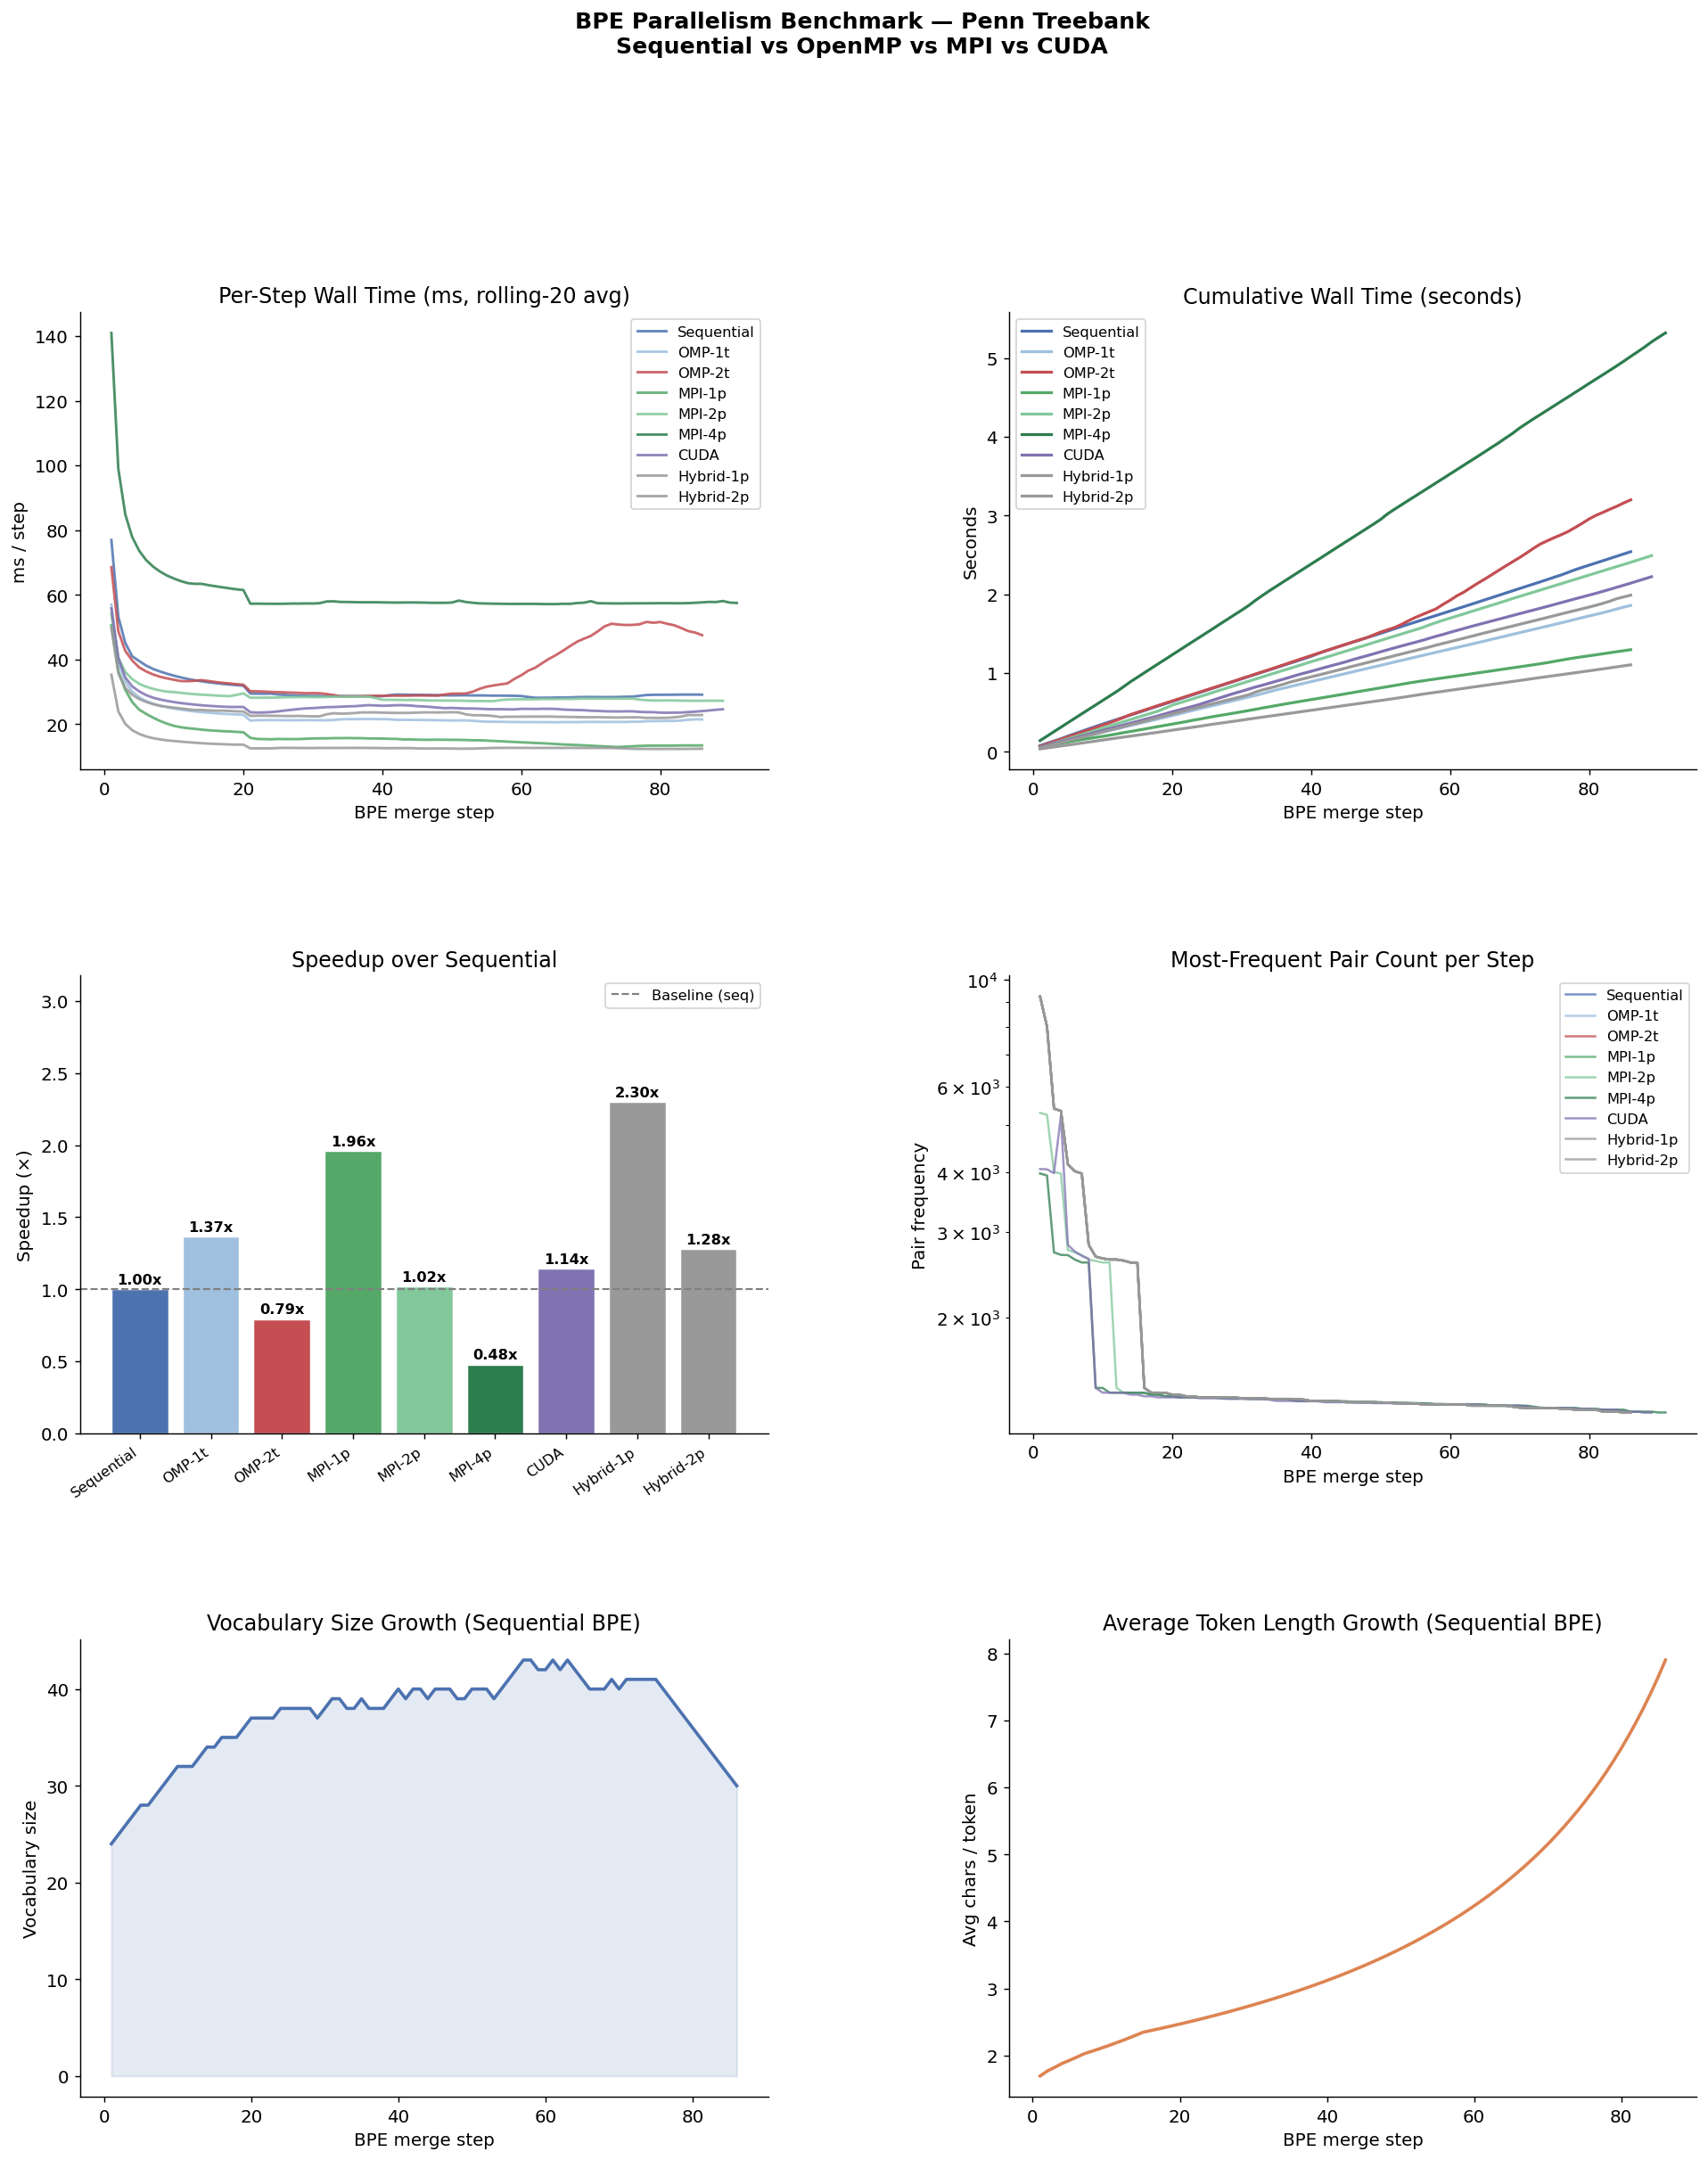

Figure saved to bpe_analysis.png


In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({'figure.dpi':130,'font.size':11,
                     'axes.spines.top':False,'axes.spines.right':False})

COLORS = {'Sequential':'#4C72B0','OMP-1t':'#9FC0DE','OMP-2t':'#DD8452',
          'OMP-4t':'#E8A97A',f'OMP-{NCORES}t':'#C44E52',
          'MPI-1p':'#55A868','MPI-2p':'#82C89A','MPI-4p':'#2E7D4F',
          'CUDA':'#8172B2'}
DEFAULT_COLOR = '#999999'

def get_color(label):
    for k,v in COLORS.items():
        if label.startswith(k) or k.startswith(label): return v
    return DEFAULT_COLOR

fig = plt.figure(figsize=(18,20))
gs  = gridspec.GridSpec(3,2,hspace=0.45,wspace=0.35)
axes = [fig.add_subplot(gs[r,c]) for r in range(3) for c in range(2)]


ax = axes[0]
for label, df in dfs.items():
    if 'wall_ms' in df.columns:
        ax.plot(df['step'], df['wall_ms'].rolling(20,min_periods=1).mean(),
                label=label, color=get_color(label), lw=1.6, alpha=0.85)
ax.set(title='Per-Step Wall Time (ms, rolling-20 avg)',
       xlabel='BPE merge step', ylabel='ms / step')
ax.legend(fontsize=9)


ax = axes[1]
for label, df in dfs.items():
    if 'wall_ms' in df.columns:
        ax.plot(df['step'], df['wall_ms'].cumsum()/1e3,
                label=label, color=get_color(label), lw=1.8)
ax.set(title='Cumulative Wall Time (seconds)',
       xlabel='BPE merge step', ylabel='Seconds')
ax.legend(fontsize=9)


ax = axes[2]
if seq_df is not None:
    seq_total = seq_df['wall_ms'].sum()
    labels_sp, speedups = [], []
    for label, df in dfs.items():
        if 'wall_ms' in df.columns:
            s = seq_total / df['wall_ms'].sum()
            labels_sp.append(label); speedups.append(s)
    colors_sp = [get_color(l) for l in labels_sp]
    bars = ax.bar(labels_sp, speedups, color=colors_sp, edgecolor='white', linewidth=0.8)
    ax.axhline(1.0, color='grey', lw=1.2, ls='--', label='Baseline (seq)')
    for bar, val in zip(bars, speedups):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.2f}x',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set(title='Speedup over Sequential', ylabel='Speedup (×)', ylim=(0, max(speedups)*1.25+0.3))
    ax.legend(fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)


ax = axes[3]
for label, df in dfs.items():
    if 'freq' in df.columns:
        ax.plot(df['step'], df['freq'],
                label=label, color=get_color(label), lw=1.4, alpha=0.75)
ax.set(title='Most-Frequent Pair Count per Step',
       xlabel='BPE merge step', ylabel='Pair frequency')
ax.set_yscale('log')
ax.legend(fontsize=9)


ax = axes[4]
if seq_df is not None and 'vocab_size' in seq_df.columns:
    ax.plot(seq_df['step'], seq_df['vocab_size'],
            color=COLORS['Sequential'], lw=2)
    ax.fill_between(seq_df['step'], seq_df['vocab_size'], alpha=0.15,
                    color=COLORS['Sequential'])
    ax.set(title='Vocabulary Size Growth (Sequential BPE)',
           xlabel='BPE merge step', ylabel='Vocabulary size')
else:
    ax.text(0.5,0.5,'vocab_size not recorded\n(only in Sequential variant)',
            ha='center',va='center',transform=ax.transAxes,color='grey')
    ax.set_title('Vocabulary Size Growth')


ax = axes[5]
if seq_df is not None and 'avg_tok_len' in seq_df.columns:
    ax.plot(seq_df['step'], seq_df['avg_tok_len'],
            color='#DD8452', lw=2)
    ax.set(title='Average Token Length Growth (Sequential BPE)',
           xlabel='BPE merge step', ylabel='Avg chars / token')
else:
    ax.text(0.5,0.5,'avg_tok_len not recorded',
            ha='center',va='center',transform=ax.transAxes,color='grey')
    ax.set_title('Average Token Length')

fig.suptitle('BPE Parallelism Benchmark — Penn Treebank\n'
             'Sequential vs OpenMP vs MPI vs CUDA',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('bpe_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved to bpe_analysis.png')


### 9b. Thread / Process Scaling (Weak + Strong)

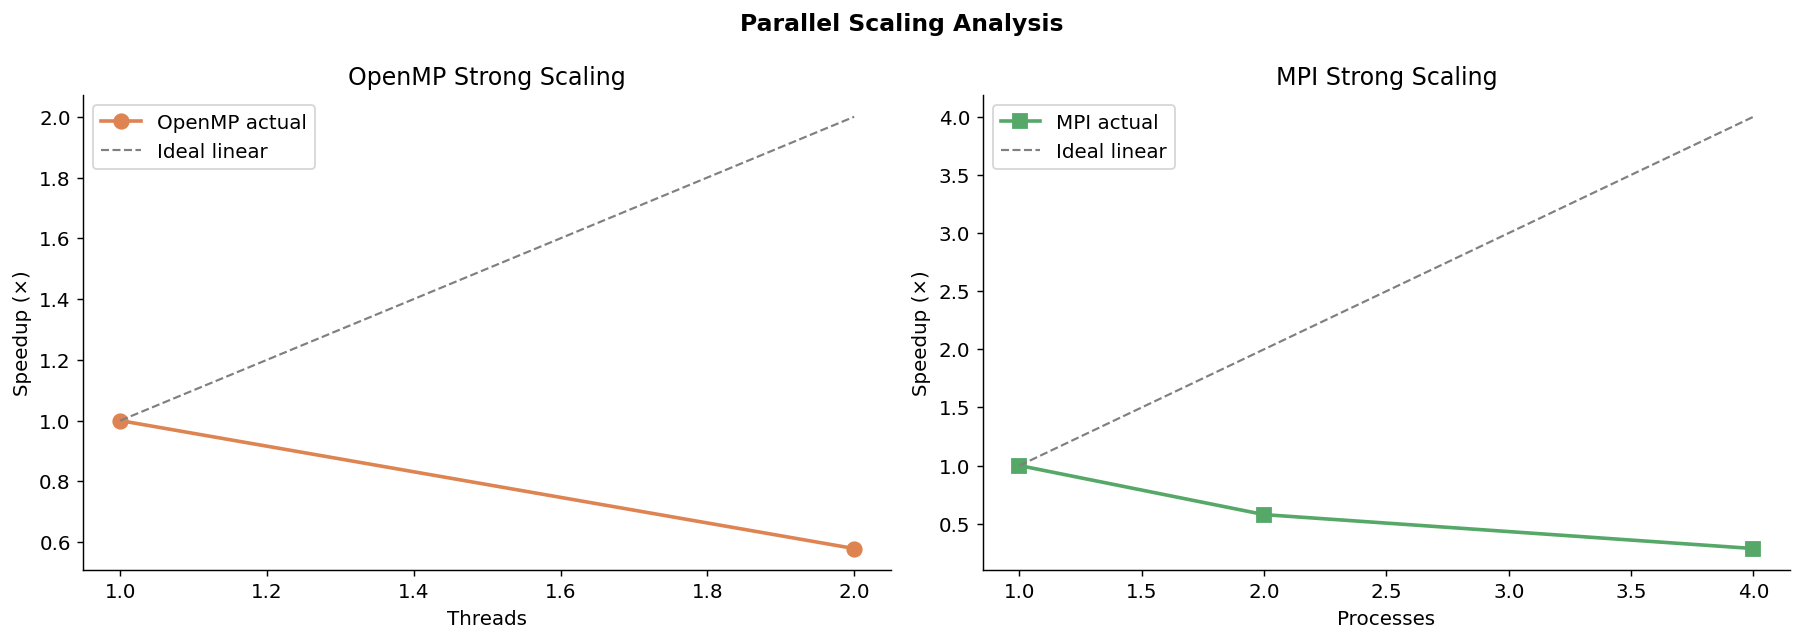

In [30]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Parallel Scaling Analysis', fontsize=13, fontweight='bold')


ax = axes2[0]
omp_data = [(int(l.split('-')[1].replace('t','')), v['time'])
            for l,v in results.items() if l.startswith('OMP')]
omp_data.sort()
if omp_data:
    threads_list, times_list = zip(*omp_data)
    t1_omp = times_list[0]
    speedups_omp = [t1_omp/t for t in times_list]
    ax.plot(threads_list, speedups_omp, 'o-',
            color='#DD8452', lw=2, ms=8, label='OpenMP actual')
    ideal = [t for t in threads_list]
    ax.plot(threads_list, ideal, '--', color='grey', lw=1.2, label='Ideal linear')
    ax.set(title='OpenMP Strong Scaling',
           xlabel='Threads', ylabel='Speedup (×)')
    ax.legend()


ax = axes2[1]
mpi_data = [(int(l.split('-')[1].replace('p','')), v['time'])
            for l,v in results.items() if l.startswith('MPI')]
mpi_data.sort()
if mpi_data:
    procs_list, ptimes = zip(*mpi_data)
    t1_mpi = ptimes[0]
    speedups_mpi = [t1_mpi/t for t in ptimes]
    ax.plot(procs_list, speedups_mpi, 's-',
            color='#55A868', lw=2, ms=8, label='MPI actual')
    ideal_m = [p for p in procs_list]
    ax.plot(procs_list, ideal_m, '--', color='grey', lw=1.2, label='Ideal linear')
    ax.set(title='MPI Strong Scaling',
           xlabel='Processes', ylabel='Speedup (×)')
    ax.legend()

plt.tight_layout()
plt.savefig('bpe_scaling.png', bbox_inches='tight', dpi=150)
plt.show()


## 10. Summary Statistics Table

In [31]:
rows = []
seq_total = dfs['Sequential']['wall_ms'].sum() if 'Sequential' in dfs else None

for label, df in dfs.items():
    if 'wall_ms' not in df.columns: continue
    total_ms = df['wall_ms'].sum()
    mean_ms  = df['wall_ms'].mean()
    speedup  = (seq_total / total_ms) if seq_total else float('nan')
    rows.append({'Variant': label,
                 'Steps': len(df),
                 'Total time (s)': f'{total_ms/1000:.2f}',
                 'Mean ms/step': f'{mean_ms:.3f}',
                 'Speedup vs Seq': f'{speedup:.2f}×'})

summary = pd.DataFrame(rows).set_index('Variant')
print(summary.to_string())
summary.to_csv('bpe_summary.csv')
print('\nSaved to bpe_summary.csv')

from google.colab import files
import os

for f in ['seq_results.csv', f'omp_{NCORES}t.csv', 'omp_1t.csv', 'omp_2t.csv',
          'mpi_1p.csv', 'mpi_2p.csv', 'mpi_4p.csv',
          'cuda_results.csv', 'hybrid_1p.csv', 'hybrid_2p.csv']:
    if os.path.exists(f): files.download(f)

            Steps Total time (s) Mean ms/step Speedup vs Seq
Variant                                                     
Sequential     86           2.54       29.532          1.00×
OMP-1t         86           1.86       21.598          1.37×
OMP-2t         86           3.20       37.187          0.79×
MPI-1p         86           1.30       15.064          1.96×
MPI-2p         89           2.49       27.974          1.02×
MPI-4p         91           5.32       58.436          0.48×
CUDA           89           2.22       24.971          1.14×
Hybrid-1p      86           1.10       12.829          2.30×
Hybrid-2p      86           1.99       23.116          1.28×

Saved to bpe_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Inspect Top BPE Merges

In [32]:
if seq_df is not None:
    print('Top-30 BPE merges by frequency:')
    top = seq_df.nlargest(30, 'freq')[['step','pair_a','pair_b','freq']]
    print(top.to_string(index=False))

    print('\nBottom-10 (rarest surviving merges):')
    bot = seq_df.nsmallest(10, 'freq')[['step','pair_a','pair_b','freq']]
    print(bot.to_string(index=False))


Top-30 BPE merges by frequency:
 step pair_a    pair_b  freq
    1      e      </w>  9233
    2      a         t  7994
    3      r      </w>  5411
    4     at      </w>  5350
    5      a         n  4147
    6      k      </w>  4014
    7      u         s  3971
    8      r        an  2826
    9      e     r</w>  2672
   10      a         i  2649
   11      t         r  2635
   12      g      </w>  2635
   13      n      </w>  2622
   14     us     e</w>  2598
   15      o   use</w>  2598
   16    ran      </w>  1429
   17      d       ran  1397
   18   dran     k</w>  1397
   19      m    at</w>  1396
   20      c         a  1384
   21     ca     r</w>  1384
   22     us      </w>  1373
   23      b    us</w>  1373
   24      e         d  1366
   25      p        ed  1366
   26      m       ped  1366
   27   mped      </w>  1366
   28      u  mped</w>  1366
   29      j umped</w>  1366
   30      l         o  1360

Bottom-10 (rarest surviving merges):
 step pair_a   pair_b  freq
   

## 12. Tokenise Sample Sentences with Learned BPE Vocabulary

In [33]:
# Reconstruct merge list from sequential CSV
def build_bpe_encoder(df, n=500):
    """Return ordered list of (a, b) merge rules."""
    merges = []
    for _, row in df.head(n).iterrows():
        merges.append((str(row['pair_a']), str(row['pair_b'])))
    return merges

def bpe_encode(word, merges):
    """Encode a single word using learned merges."""
    tokens = list(word) + ['</w>']
    for a, b in merges:
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens)-1 and tokens[i]==a and tokens[i+1]==b:
                new_tokens.append(a+b); i += 2
            else:
                new_tokens.append(tokens[i]); i += 1
        tokens = new_tokens
    return tokens

if seq_df is not None:
    merges = build_bpe_encoder(seq_df, n=500)
    samples = ['playing','tokenization','unconstitutional',
               'corporation','washington','earthquake','the','a']
    print(f'{'Word':25s}  Tokens')
    print('-'*60)
    for w in samples:
        toks = bpe_encode(w, merges)
        print(f'{w:25s}  {toks}')


Word                       Tokens
------------------------------------------------------------
playing                    ['pl', 'a', 'y', 'i', 'n', 'g</w>']
tokenization               ['t', 'o', 'k', 'en', 'i', 'z', 'at', 'i', 'on</w>']
unconstitutional           ['u', 'n', 'c', 'o', 'n', 's', 't', 'i', 't', 'u', 't', 'i', 'o', 'n', 'a', 'l', '</w>']
corporation                ['c', 'o', 'r', 'p', 'o', 'r', 'at', 'i', 'on</w>']
washington                 ['w', 'a', 's', 'hi', 'n', 'g', 't', 'on</w>']
earthquake                 ['e', 'a', 'r', 'th', 'q', 'u', 'a', 'k', 'e</w>']
the                        ['the</w>']
a                          ['a</w>']


## 13. Pair-Type Heatmap (Character n-grams merged)

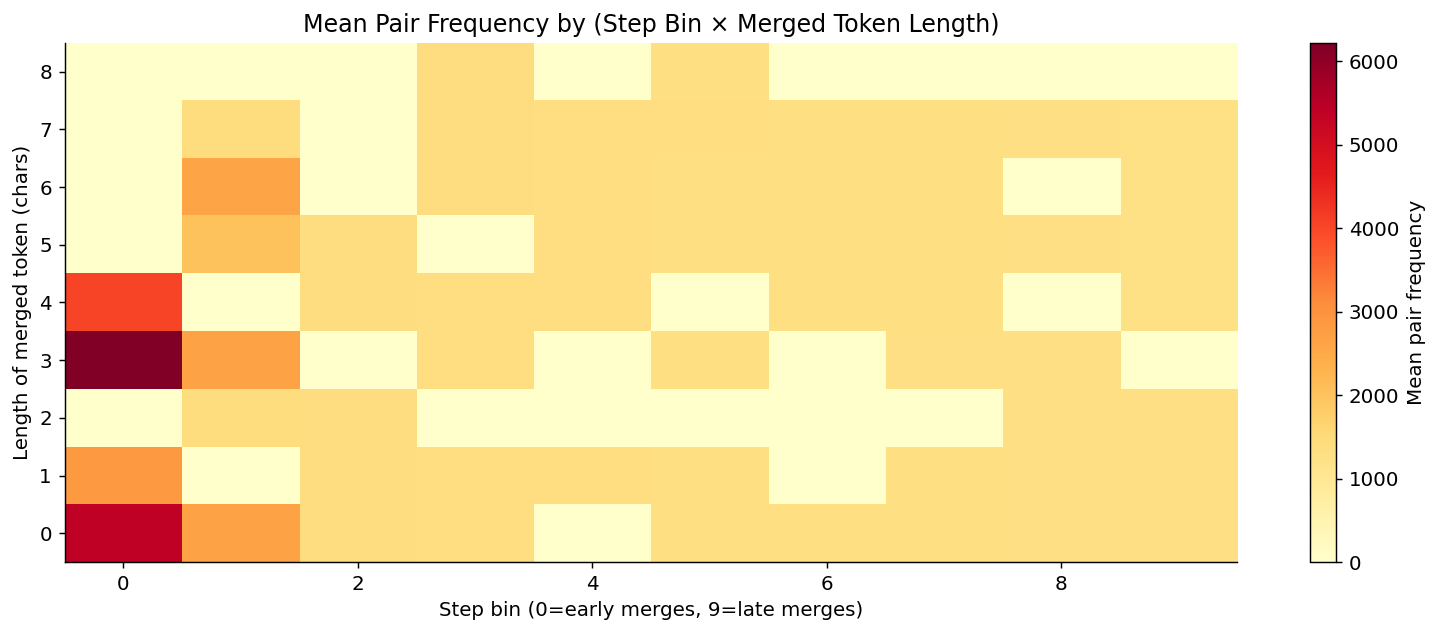

In [34]:
if seq_df is not None:
    # Categorise merges by length of resulting token
    seq_df['merged_len'] = seq_df['pair_a'].str.len() + seq_df['pair_b'].str.len()
    seq_df['step_bin'] = pd.cut(seq_df['step'], bins=10, labels=False)

    pivot = seq_df.groupby(['step_bin','merged_len'])['freq'].mean().unstack(fill_value=0)

    fig3, ax3 = plt.subplots(figsize=(12,5))
    im = ax3.imshow(pivot.T, aspect='auto', cmap='YlOrRd', origin='lower')
    ax3.set_xlabel('Step bin (0=early merges, 9=late merges)')
    ax3.set_ylabel('Length of merged token (chars)')
    ax3.set_title('Mean Pair Frequency by (Step Bin × Merged Token Length)')
    plt.colorbar(im, ax=ax3, label='Mean pair frequency')
    plt.tight_layout()
    plt.savefig('bpe_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


## 14. Design Notes & Complexity

| Variant | Pair-count complexity | Merge complexity | Notes |
|---|---|---|---|
| **Sequential** | O(V·L) | O(V·L) | V=vocab size, L=avg token len |
| **OpenMP** | O(V·L / T) | O(V·L / T) | T threads; merge-table merge O(T·H) |
| **MPI** | O(V·L / P) counting | O(V·L) apply | P ranks; apply broadcast is bottleneck |
| **CUDA** | O(V·L / G) | O(V·L) host | G GPU threads; PCIe transfer each step |

### Bottlenecks
- **OpenMP**: hash-table merge phase is serial — limits scaling beyond ~8 threads.
- **MPI**: full-vocab apply after broadcast is replicated on all ranks → communicate only the merge rule, not counts.
- **CUDA**: PCIe round-trip per step dominates for small vocabularies. Batching multiple merges per kernel launch would help.

### Improvements
- Use a **min-heap / priority queue** instead of linear hash scan for O(log N) best-pair lookup.
- **Incremental update**: only recount pairs involving the newly merged symbol.
- **GPU**: keep vocabulary fully on device; only copy the winning merge rule (two short strings).
- **MPI + OpenMP hybrid**: each MPI rank uses multiple OMP threads.
